# 03 Clustering Experiments

**Goal:** Evaluate the quality of semantic clusters and explore their structure across transcript chunks.

This notebook covers:
- Cluster size distribution across 20 clusters
- Top chunk labels per cluster and cluster-level summaries (top labels, sentiment distribution, sample summaries)
- Intra-cluster cosine similarity to measure how tight each cluster is
- Inter-cluster centroid similarity to identify clusters that overlap
- UMAP visualisation of all chunk embeddings coloured by cluster ID
- Clustering quality metrics: silhouette score (cosine), Davies-Bouldin index, Calinski-Harabasz score
- Experiments with different numbers of clusters (8, 10, 12, 15, 20, 25, 30) to compare metrics
- Hierarchical dendrogram of chunk embeddings using cosine distance
- Manual inspection of specific clusters (0, 1, 19)
- Theme × call_type sentiment cross-tab
- Cross-domain chunk identification
- Sub-clustering of cluster 0 into 2 sub-clusters


In [166]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity


BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

CLUSTERED_CHUNKS_PATH = (
    BASE_DIR
    / "data"
    / "processed"
    / "clustered_chunks"
    / "clustered_chunks_flat.json"
)

with open(CLUSTERED_CHUNKS_PATH, "r", encoding="utf-8") as f:
    clustered_chunks = json.load(f)

cluster_df = pd.DataFrame(clustered_chunks)

cluster_df.head()

,meeting_id,meeting_title,chunk_id,start_turn,end_turn,start_time,end_time,chunk_label,chunk_summary,chunk_text,...,is_cross_domain,call_type,invitee_domains,embedding_model,embedding,is_scaffolding,scaffolding_reason,cluster_id,cluster_name,clustering_method
0,01KQ03B0303900521BB089CA,Detect Outage - Remediation Plan Review,01KQ03B0303900521BB089CA_CHUNK_001,0,3,7.4,41.0,Outage Overview,Team discusses current outage status and need for remediation plan.,"Megan Lawson: Alright, I think we're all on — Raj, Brian, can you both hear me okay?\nRaj Kapoor: Yeah, I'm here. Audio's good.\nBrian Cho: Yep, I'm on. Give me one sec, I'm just pulling up the incident doc.\nMegan Lawson: Sure, take your time. So, uh, the reason I wanted to get us together today — obviously we're still in the middle of this, day three of the outage window — I want to make sure we have a clear remediation plan and that we're all aligned before we send anything else externally.",...,False,internal_operational,[aegiscloud.com],BAAI/bge-large-en-v1.5,"[-0.0076064495369791985, -0.012960203923285007, -0.06597937643527985, 0.050067368894815445, -0.0010541838128119707, -0.01872098259627819, -0.026665721088647842, -0.013858544640243053, 0.05267244204878807, 0.02102707326412201, 0.03856760635972023, -0.004624257795512676, 0.03505675867199898, -0.006768764927983284, -0.04537932202219963, -0.014892270788550377, -0.03677992522716522, -0.016193699091672897, -0.023262815549969673, -0.01331480871886015, -0.026097029447555542, 0.03316730260848999, 0.008193066343665123, 0.018896527588367462, -0.07473023980855942, 0.021761421114206314, -0.013759930618107319, -0.014151482842862606, 0.050354186445474625, 0.044405072927474976, -0.07128036022186279, -0.028919680044054985, -0.03345244750380516, -0.026657909154891968, 0.031069861724972725, -0.01918422430753708, 0.026232782751321793, -0.033265918493270874, -0.05254150554537773, -0.07777867466211319, -0.02256813645362854, 0.013391067273914814, 0.09316838532686234, -0.04596003517508507, -0.046111881732940674, 0.010773962363600731, -0.03341313824057579, 0.005990170873701572, 0.0018527003703638911, 0.001660606823861599, 0.006686515640467405, 0.03951900079846382, -0.02643534354865551, -0.014447126537561417, 0.024054888635873795, -0.024936039000749588, -0.02005438506603241, 0.059701692312955856, -0.04530056565999985, -0.015825659036636353, 0.02813940867781639, 0.006123639177531004, 0.007597514893859625, -0.042446333914995193, 0.017701786011457443, 0.07745950669050217, -0.054710421711206436, -0.010185700841248035, -0.00701520498842001, 0.021843522787094116, -0.024086739867925644, 0.009063179604709148, -0.05217580497264862, -0.015887083485722542, 0.013404816389083862, -0.005374599248170853, -0.029010767117142677, 0.00849701277911663, -0.026547633111476898, 0.05524134635925293, -0.006116484757512808, 0.014189505018293858, 0.009376353584229946, -0.01240593008697033, -0.0015742836985737085, -0.014344466850161552, 0.03023669496178627, -6.910367665113881e-05, 0.020882397890090942, 0.01818186789751053, 0.013194647617638111, 0.037749603390693665, -0.008743333630263805, -0.0023906640708446503, 0.02733246609568596, 0.02889348194003105, -0.03209322318434715, -0.0013721499126404524, -0.024597574025392532, 0.04208908975124359, ...]",False,substantive,0,None,agglomerative
1,01KQ03B0303900521BB089CA,Detect Outage - Remediation Plan Review,01KQ03B0303900521BB089CA_CHUNK_002,4,15,42.3,210.0,Root Cause Analysis,Agent explains the cascading failure and proposed fixes for the outage.,"Raj Kapoor: Yeah, agreed. I've been heads-down with the engineering team since Saturday and I think we have a pretty solid picture of the root cause at this point. Do you want me to just walk through it?\nMegan Lawson: Please, yeah. Go ahead.\nRaj Kapoor: Okay so — and Brian, let me know if the technical depth here is useful for you or if you want me to translate as I go — basically what we're looking at is a cascading failure in the event processing pipeline. The short version i

In [167]:
cluster_sizes = cluster_df["cluster_id"].value_counts().sort_index()

cluster_sizes

cluster_id
0     99
1     13
2     82
3     35
4      7
5      4
6     46
7     44
8      2
9      8
10     5
11     1
12     1
13     1
14     7
15     1
16     5
17     2
18     6
19     9
Name: count, dtype: int64

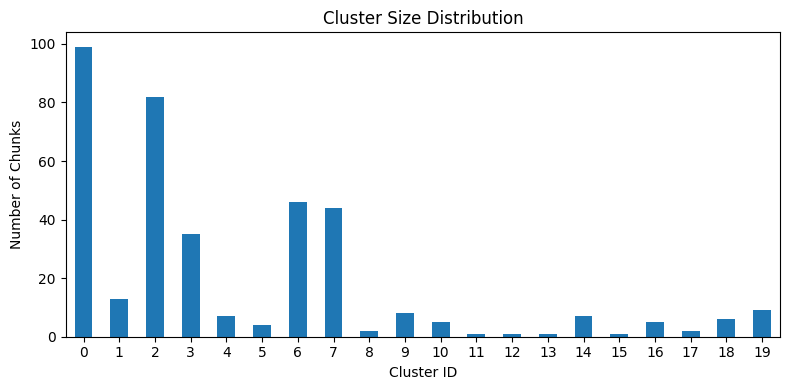

In [168]:
plt.figure(figsize=(8, 4))
cluster_sizes.plot(kind="bar")

plt.title("Cluster Size Distribution")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Chunks")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [169]:
top_labels_per_cluster = (
    cluster_df
    .groupby("cluster_id")["chunk_label"]
    .value_counts()
    .groupby(level=0)
    .head(10)
    .reset_index(name="count")
)

top_labels_per_cluster

,cluster_id,chunk_label,count
0,0,Root Cause Analysis,5
1,0,Incident Overview,4
2,0,Platform Outage,4
3,0,Incident Review,3
4,0,Root Cause Investigation,3
5,0,Service Outage,3
6,0,Alert Latency Issue,2
7,0,Backup Performance Issue,2
8,0,Incident Investigation,2
9,0,SLA Discussion,2


In [170]:
cluster_summary_rows = []

for cluster_id, group in cluster_df.groupby("cluster_id"):
    top_labels = group["chunk_label"].value_counts().head(5).to_dict()
    top_sentiments = group["chunk_sentiment"].value_counts().to_dict()

    cluster_summary_rows.append({
        "cluster_id": cluster_id,
        "chunk_count": len(group),
        "top_labels": top_labels,
        "sentiment_distribution": top_sentiments,
        "sample_summaries": group["chunk_summary"].head(3).tolist(),
    })

cluster_summary_df = pd.DataFrame(cluster_summary_rows).sort_values(
    "chunk_count",
    ascending=False
)

cluster_summary_df

,cluster_id,chunk_count,top_labels,sentiment_distribution,sample_summaries
0,0,99,"{'Root Cause Analysis': 5, 'Platform Outage': 4, 'Incident Overview': 4, 'Service Outage': 3, 'Root Cause Investigation': 3}","{'negative': 34, 'neutral': 26, 'mixed-negative': 22, 'positive': 11, 'mixed-positive': 5, 'very-negative': 1}","[Team discusses current outage status and need for remediation plan., Agent explains the cascading failure and proposed fixes for the outage., Team discusses threat monitoring data during outage and retroactive analysis.]"
2,2,82,"{'Deployment Planning': 3, 'Access Control Review': 2, 'Identity Management Discussion': 2, 'Audit Preparation': 2, 'Q2 Roadmap Planning': 2}","{'positive': 32, 'neutral': 25, 'negative': 12, 'mixed-negative': 8, 'mixed-positive': 4, 'very-positive': 1}","[Discussion on access control measures and log retention for audit., Identifying issues in change management process and hotfixes., Discussion on incident tracking and integration challenges.]"
6,6,46,"{'Compliance Update': 3, 'Compliance Reporting': 2, 'Product Launch': 2, 'Next Steps Planning': 2, 'Product Roadmap Insights': 2}","{'positive': 30, 'neutral': 10, 'mixed-negative': 2, 'mixed-positive': 2, 'negative': 2}","[Discussion on resource allocation and timeline for Comply v2 launch., Overview of Comply v2 features and benefits for ISO compliance., Planning next steps for ISO 27001 certification and Comply v2 activation.]"
7,7,44,"{'Next Steps': 12, 'Action Items': 6, 'Action Items and Next Steps': 3, 'Next Steps and Follow-Up': 3, 'Follow-Up Assurance': 2}","{'positive': 26, 'neutral': 18}","[Summarizing action items and planning next steps., Agent confirms proposal details and next steps for contract renewal., Agent outlines next steps for renewal proposal and engineering call.]"
3,3,35,"{'Renewal Discussion': 4, 'Customer Communication': 2, 'Renewal Concerns': 2, 'Contract Renewal Discussion': 2, 'Contract Renewal': 2}","{'positive': 14, 'neutral': 10, 'mixed-negative': 5, 'negative': 5, 'mixed-positive': 1}","[Discussion on updating customers about visibility restoration timeline., Agent discusses upcoming contract renewal and pricing adjustments., Agent and customer discuss upcoming contract renewal and billing questions.]"
1,1,13,"{'Onboarding Introduction': 3, 'Onboarding Process': 2, 'Implementation Timeline': 2, 'ISO 27001 Introduction': 1, 'Current ISO Status': 1}","{'positive': 12, 'mixed-negative': 1}","[Introduction of team members and discussion of ISO 27001 preparation needs., Discussion of current ISO 27001 status and challenges faced., Discussion on onboarding new sites and support during expansion.]"
19,19,9,"{'Sprint Planning': 4, 'Sprint Retrospective': 3, 'Pipeline Reliability': 1, 'Process Improvement': 1}","{'neutral': 5, 'mixed-negative': 2, 'positive': 2}","[Team discusses progress and timeline for Detect pipeline reliability work., Review of sprint board and ticket status updates., Review of sprint twenty-two, including blockers and completed tasks.]"
9,9,8,"{'Root Cause Analysis': 2, 'Circuit Breaker Review': 1, 'Pipeline Architecture': 1, 'Incident Remediation': 1, 'Recovery Objectives': 1}","{'neutral': 3, 'negative': 3, 'mixed-positive': 1, 'positive': 1}","[Discussion on circuit breaker PR and necessary health check implementation., Investigation reveals a single point of failure in the ingestion layer., Identifying architectural risks in the event ingestion pipeline.]"
4,4,7,"{'Competitive Positioning': 1, 'Product Launch Planning': 1, 'Adaptive MFA Policies': 1, 'Competitive Landscape': 1, 'Q1 Win-Loss Analysis': 1}","{'neutral': 3, 'negative': 2, 'positive': 2}","[Analyzing competitor responses and developing counter-narratives., Aligning the upcoming product launch with customer engagement strategies., Exploration of adaptive MFA policies and competitive positioning.]"
14,14,7,"{'Competitive Evaluation': 1, 'Renewal Proposal': 1, 'Service Performance Review': 1, 'Infrastructure Concerns': 1, 

In [171]:
embedding_matrix = np.array(cluster_df["embedding"].tolist())

def avg_intra_cluster_similarity(indices):
    if len(indices) <= 1:
        return None

    vectors = embedding_matrix[indices]
    sim_matrix = cosine_similarity(vectors)

    upper_triangle = sim_matrix[np.triu_indices_from(sim_matrix, k=1)]

    return float(np.mean(upper_triangle))


intra_cluster_rows = []

for cluster_id, group in cluster_df.groupby("cluster_id"):
    indices = group.index.tolist()

    intra_cluster_rows.append({
        "cluster_id": cluster_id,
        "chunk_count": len(group),
        "avg_intra_cluster_similarity": avg_intra_cluster_similarity(indices),
    })

intra_cluster_df = pd.DataFrame(intra_cluster_rows).sort_values(
    "avg_intra_cluster_similarity",
    ascending=True,
    na_position="last"
)

intra_cluster_df

/Users/swatithapaswatithapa/Documents/study/transcript-mining/trans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/swatithapaswatithapa/Documents/study/transcript-mining/trans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/swatithapaswatithapa/Documents/study/transcript-mining/trans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/swatithapaswatithapa/Documents/study/transcript-mining/trans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/swatithapaswatithapa/Documents/study/transcript-mining/trans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/swatithapaswatithapa/Documents/study

,cluster_id,chunk_count,avg_intra_cluster_similarity
2,2,82,0.637662
0,0,99,0.644777
8,8,2,0.654291
4,4,7,0.654986
9,9,8,0.666313
10,10,5,0.667365
3,3,35,0.676873
6,6,46,0.681622
18,18,6,0.682018
19,19,9,0.695374


In [172]:
cluster_centroids = []
cluster_ids = []

for cluster_id, group in cluster_df.groupby("cluster_id"):
    indices = group.index.tolist()
    centroid = embedding_matrix[indices].mean(axis=0)

    cluster_centroids.append(centroid)
    cluster_ids.append(cluster_id)

cluster_centroids = np.array(cluster_centroids)

cluster_sim_matrix = cosine_similarity(cluster_centroids)

inter_cluster_pairs = []

for i in range(len(cluster_ids)):
    for j in range(i + 1, len(cluster_ids)):
        inter_cluster_pairs.append({
            "cluster_id_1": cluster_ids[i],
            "cluster_id_2": cluster_ids[j],
            "centroid_similarity": cluster_sim_matrix[i, j],
        })

inter_cluster_df = pd.DataFrame(inter_cluster_pairs).sort_values(
    "centroid_similarity",
    ascending=False,
)

inter_cluster_df.head(20)

,cluster_id_1,cluster_id_2,centroid_similarity
40,2,6,0.900484
2,0,3,0.890796
43,2,9,0.885202
1,0,2,0.879880
19,1,2,0.869350
56,3,6,0.868766
5,0,6,0.858901
23,1,6,0.858634
8,0,9,0.858186
99,6,7,0.857988


In [173]:
largest_cluster_id = cluster_sizes.idxmax()

largest_cluster_review = cluster_df[
    cluster_df["cluster_id"] == largest_cluster_id
][
    [
        "cluster_id",
        "meeting_id",
        "chunk_id",
        "chunk_label",
        "chunk_summary",
        "chunk_sentiment",
        "matched_provided_topics",
    ]
]

largest_cluster_review.head(30)

,cluster_id,meeting_id,chunk_id,chunk_label,chunk_summary,chunk_sentiment,matched_provided_topics
0,0,01KQ03B0303900521BB089CA,01KQ03B0303900521BB089CA_CHUNK_001,Outage Overview,Team discusses current outage status and need for remediation plan.,neutral,[incident response]
1,0,01KQ03B0303900521BB089CA,01KQ03B0303900521BB089CA_CHUNK_002,Root Cause Analysis,Agent explains the cascading failure and proposed fixes for the outage.,neutral,[outage remediation]
3,0,01KQ03B0303900521BB089CA,01KQ03B0303900521BB089CA_CHUNK_004,Security Assurance,Team discusses threat monitoring data during outage and retroactive analysis.,neutral,[security monitoring]
6,0,01KQ0C1280EDA4E70AAD7C35,01KQ0C1280EDA4E70AAD7C35_CHUNK_002,Migration Cleanup,Agent investigates provisioning logs and identifies undeprovisioned migration test accounts as the source of the seat overage.,neutral,"[migration cleanup, provisioning]"
7,0,01KQ0C1280EDA4E70AAD7C35,01KQ0C1280EDA4E70AAD7C35_CHUNK_003,Preventive Monitoring,Customer and agent discuss alerting mechanisms to avoid future seat overages.,positive,[identity management]
15,0,01KQ0F8AFF3DA34FD4580008,01KQ0F8AFF3DA34FD4580008_CHUNK_001,Detect Outage Review,Discussion on March outage impact and remediation steps taken.,mixed-negative,[outage]
24,0,01KQ1A6B7E81B06F4A13B60D,01KQ1A6B7E81B06F4A13B60D_CHUNK_001,Backup Performance Issue,Customer reports significant slowdown in nightly backup jobs over three weeks.,mixed-negative,"[backup performance, technical issue]"
25,0,01KQ1A6B7E81B06F4A13B60D,01KQ1A6B7E81B06F4A13B60D_CHUNK_002,Agent Version Update,Agent identifies potential performance issue with outdated backup agent version.,mixed-positive,"[agent version update, notification gap]"
26,0,01KQ1A6B7E81B06F4A13B60D,01KQ1A6B7E81B06F4A13B60D_CHUNK_003,Escalation Plan,Customer requests escalation if performance issues persist after upgrade.,mixed-negative,"[escalation, customer retention]"
31,0,01KQ1DCC80852AE384C898C9,01KQ1DCC80852AE384C898C9_CHUNK_001,Service Outage,Customer reports significant outage and communication failures from Aegis Detect.,negative,[outage]


/Users/swatithapaswatithapa/Documents/study/transcript-mining/trans/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


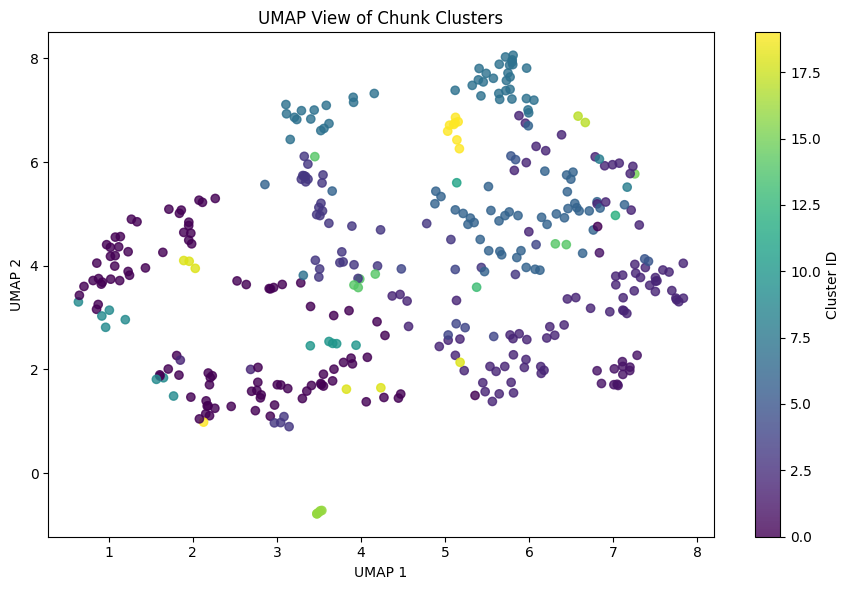

In [174]:
# Install once if needed:
# pip install umap-learn

import umap

reducer = umap.UMAP(
    n_neighbors=10,
    min_dist=0.1,
    metric="cosine",
    random_state=42,
)

umap_embeddings = reducer.fit_transform(embedding_matrix)

cluster_df["umap_x"] = umap_embeddings[:, 0]
cluster_df["umap_y"] = umap_embeddings[:, 1]

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    cluster_df["umap_x"],
    cluster_df["umap_y"],
    c=cluster_df["cluster_id"],
    alpha=0.8,
)

plt.title("UMAP View of Chunk Clusters")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(scatter, label="Cluster ID")
plt.tight_layout()
plt.show()

In [175]:
clustering_quality_summary = {
    "total_chunks": len(cluster_df),
    "total_clusters": cluster_df["cluster_id"].nunique(),
    "largest_cluster_size": int(cluster_sizes.max()),
    "largest_cluster_ratio": round(cluster_sizes.max() / len(cluster_df), 3),
    "smallest_cluster_size": int(cluster_sizes.min()),
    "avg_intra_cluster_similarity": round(
        intra_cluster_df["avg_intra_cluster_similarity"].dropna().mean(),
        3,
    ),
    "highest_inter_cluster_similarity": round(
        inter_cluster_df["centroid_similarity"].max(),
        3,
    ),
}

clustering_quality_summary

{'total_chunks': 378,
 'total_clusters': 20,
 'largest_cluster_size': 99,
 'largest_cluster_ratio': np.float64(0.262),
 'smallest_cluster_size': 1,
 'avg_intra_cluster_similarity': np.float64(0.695),
 'highest_inter_cluster_similarity': np.float64(0.9)}

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist


# Cosine distance works well because embeddings were normalized
distance_matrix = pdist(embedding_matrix, metric="cosine")

linked = linkage(
    distance_matrix,
    method="average"
)

plt.figure(figsize=(16, 7))

dendrogram(
    linked,
    labels=cluster_df["chunk_label"].tolist(),
    leaf_rotation=90,
    leaf_font_size=8,
)

plt.title("Hierarchical Clustering Dendrogram of Semantic Chunks")
plt.xlabel("Semantic Chunks")
plt.ylabel("Cosine Distance")

plt.tight_layout()
plt.show()

In [176]:
def inspect_cluster(cluster_id, max_rows=20):
    cluster_view = cluster_df[
        cluster_df["cluster_id"] == cluster_id
    ][
        [
            "meeting_id",
            "chunk_id",
            "chunk_label",
            "chunk_summary",
            "chunk_sentiment",
            "matched_provided_topics",
        ]
    ]

    print(f"Cluster ID: {cluster_id}")
    print(f"Total chunks: {len(cluster_view)}")

    return cluster_view.head(max_rows)

In [177]:
pd.set_option("display.max_colwidth", None)

In [178]:
cluster_view = cluster_df[
    cluster_df["cluster_id"] == 19
][
    [
        "chunk_label",
        "chunk_summary",
        "chunk_text",
    ]
]

display(cluster_view)

,chunk_label,chunk_summary,chunk_text
8,Pipeline Reliability,Team discusses progress and timeline for Detect pipeline reliability work.,"Chris Lee: Alright, I think we've got everyone on now — Tom, you there?\nTom Bradley: Yeah, I'm here, sorry — had to jump off another call, go ahead.\nChris Lee: No worries. Okay, so usual format — let's do a quick status round, then I want to spend some time on the Detect pipeline work and the Comply v2 timeline. Mike, you want to kick us off?\nMike Romano: Sure. So on my end, I've been heads down on the event ingestion refactor. We're about sixty percent through the work — the new queue partitioning is done, and I've got a draft PR up for the retry logic. Still need to wire up the dead letter queue handling and then we can start integration testing.\nChris Lee: And that's all under the Detect reliability track, right?\nMike Romano: Yeah, exactly. It's all scoped to the pipeline work.\nChris Lee: Good. Tyler, how about you?\nTyler Washington: Um, so I finished up the alert deduplication changes last week — those are merged. Right now I'm picking up the monitoring dashboard tickets that got bumped from last sprint. There's like three or four of them, they're not huge but they've been sitting there for a while.\nChris Lee: Yeah those have been in the backlog forever, good to finally get to them. Any blockers?\nTyler Washington: Not right now. I might need some time with Mike later this week to ask a few questions about how the ingestion layer works because some of the dashboard stuff pulls from there, but nothing blocking me today.\nMike Romano: Yeah that's fine, just ping me, we can do a quick thirty minutes.\nTyler Washington: Cool, thanks.\nChris Lee: Okay, Tom, anything from your side before we get into the weeds on the pipeline stuff?\nTom Bradley: Yeah, a couple things. One — I had a conversation with product Friday and they're asking again about the timeline for the Detect reliability work. They want to know if we're still comfortable with end of March. And two — the Comply v2 launch is tracking for early April, so I want to make sure we haven't over-allocated anyone against Detect to where we can't support any last-minute Comply stuff."
10,Sprint Planning,Review of sprint board and ticket status updates.,"Chris Lee: Will do. Alright, anything else on Comply before we move on? ... No? Okay. Let me just do a quick check on the sprint board — we've got eight tickets in progress, two in review. The two in review are Tyler's dedup changes — wait, those are merged already.\nTyler Washington: Yeah they should show as done, I closed them out Friday.\nChris Lee: Board probably just hasn't updated. I'll fix it after this call. Okay so eight in progress, nothing blocking at the moment. Mike, when do you think the PR will be ready for review — the retry logic one?\nMike Romano: Probably Wednesday. It's in draft right now, I want to clean it up a bit before I move it to ready. There's some stuff in there I'm not fully happy with yet.\nChris Lee: That's fine. I'll plan to take a look Thursday then. Alright, I think that covers everything — Tom, anything before we close out?\nTom Bradley: No, I'm good. Good check-in, appreciate the transparency on the timeline stuff. Keep me posted if anything changes.\nChris Lee: Will do. Alright everyone, have a good week.\nMike Romano: Thanks, you too.\nTyler Washington: Yeah, take it easy."
91,Sprint Retrospective,"Review of sprint twenty-two, including blockers and completed tasks.","Nina Kowalski: Alright, I think we're all here — let me just pull up the retro board real quick.\nTyler Washington: Yeah I'm here, just give me one second, my Slack is going crazy right now.\nSofia Petrov: Same, the Detect outage stuff is still causing a lot of noise even two weeks later.\nMike Romano: Yeah, let's try to stay focused on Identity sprint stuff today though — we can't let the Detect fallout bleed into every single retro.\nNina Kowalski: Agreed, okay so — I have the boa

In [179]:
cluster_view = cluster_df[
    cluster_df["cluster_id"] == 1
][
    [
        "chunk_label",
        "chunk_summary",
        "chunk_text",
    ]
]

display(cluster_view)

chunk_label  \
11        ISO 27001 Introduction   
12            Current ISO Status   
136       Onboarding and Support   
147           Onboarding Process   
148      Implementation Timeline   
152           Onboarding Process   
256      Onboarding Introduction   
257  Onboarding Process Overview   
268      Onboarding Introduction   
299   Onboarding and Integration   
327      Onboarding Introduction   
329      Implementation Timeline   
339              In-app Guidance   

                                                                      chunk_summary  \
11      Introduction of team members and discussion of ISO 27001 preparation needs.   
12                     Discussion of current ISO 27001 status and challenges faced.   
136                Discussion on onboarding new sites and support during expansion.   
147              Discussion on onboarding for the new compliance reporting version.   
148            Setting timelines for the rollout and onboarding of the new version.   
152    Agent outlines phased onboarding approach and training support for the team.   
256                    Agent welcomes customer and discusses backup solution needs.   
257                              Agent outlines the onboarding timeline and phases.   
268           Introduction of team members and setting the agenda for the workshop.   
299                   Details on onboarding process and support during integration.   
327  Team introductions and overview of onboarding goals for identity module setup.   
329      Agent outlines setup process, timeline, and initial steps for SSO and MFA.   
339                        Review of in-app guidance and onboarding flow for users.   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [180]:
cluster_view = cluster_df[
    cluster_df["cluster_id"] == 0
][
    [
        "chunk_label",
        "chunk_summary",
        "chunk_text",
    ]
]

display(cluster_view)

,chunk_label,chunk_summary,chunk_text
0,Outage Overview,Team discusses current outage status and need for remediation plan.,"Megan Lawson: Alright, I think we're all on — Raj, Brian, can you both hear me okay?\nRaj Kapoor: Yeah, I'm here. Audio's good.\nBrian Cho: Yep, I'm on. Give me one sec, I'm just pulling up the incident doc.\nMegan Lawson: Sure, take your time. So, uh, the reason I wanted to get us together today — obviously we're still in the middle of this, day three of the outage window — I want to make sure we have a clear remediation plan and that we're all aligned before we send anything else externally."
1,Root Cause Analysis,Agent explains the cascading failure and proposed fixes for the outage.,"Raj Kapoor: Yeah, agreed. I've been heads-down with the engineering team since Saturday and I think we have a pretty solid picture of the root cause at this point. Do you want me to just walk through it?\nMegan Lawson: Please, yeah. Go ahead.\nRaj Kapoor: Okay so — and Brian, let me know if the technical depth here is useful for you or if you want me to translate as I go — basically what we're looking at is a cascading failure in the event processing pipeline. The short version is we had a single point of failure in the event ingestion layer, and when that node went down, there was no fallback. So events just started backing up and then the whole downstream monitoring stack lost visibility.\nBrian Cho: Yeah no that's — that's helpful context actually. My team has been getting hammered with tickets since Saturday morning and I want to make sure I understand what I'm telling customers, so.\nMegan Lawson: How many tickets are we at now, roughly?\nBrian Cho: As of this morning we're at a hundred and twelve open cases specifically tied to the Detect outage. About thirty of those are priority one or two accounts. We've got a handful of customers that are, uh, pretty vocal about it.\nMegan Lawson: Okay. That's — yeah, that tracks with what I've been seeing from the account side. Raj, continuing on the root cause — what's the fix look like?\nRaj Kapoor: So the fix is two-pronged. The immediate thing we're doing — and this is already in progress, the team started on it yesterday — is deploying redundant processing nodes. So instead of relying on a single ingestion point, we're moving to an active-active configuration. That should eliminate the single point of failure entirely.\nMegan Lawson: And the second piece?\nRaj Kapoor: The second piece is implementing a circuit breaker pattern on the pipeline. So essentially, if one component starts degrading, the circuit breaker trips before it can take down the whole chain. It's a more resilient architecture overall. We should have had this from the start, honestly, but — yeah.\nMegan Lawson: I appreciate you saying that. I think — and I want to be candid here — I think there's going to be a postmortem conversation about how this got built the way it did, but I want to table that for now and focus on the remediation. What's the timeline looking like for full restoration?\nRaj Kapoor: Current estimate is we'll have the redundant nodes live by end of day today. The circuit breaker implementation is a little more involved — that's probably forty-eight hours from now, so, Wednesday evening at the earliest. But the monitoring visibility issue, the core thing customers are experiencing, that should be resolved today."
3,Security Assurance,Team discusses threat monitoring data during outage and retroactive analysis.,"Megan Lawson: I can help draft the updated customer communication if that's useful, Brian. I think we should have something that acknowledges the delay, explains the phased rollout without getting too deep in the weeds technically, and gives them the concrete timeline.\nBrian Cho: Yeah, that would actually be really helpful. My team is stretched pretty thin right now.\nMegan Lawson: Raj, on the six hours of no visibility — I want to make sure I understand this correctly. During tha

In [182]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

X = np.array(cluster_df["embedding"].tolist())
labels = cluster_df["cluster_id"].values

metrics = {
    "silhouette_cosine": silhouette_score(X, labels, metric="cosine"),
    "davies_bouldin": davies_bouldin_score(X, labels),
    "calinski_harabasz": calinski_harabasz_score(X, labels),
}

metrics

/Users/swatithapaswatithapa/Documents/study/transcript-mining/trans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/swatithapaswatithapa/Documents/study/transcript-mining/trans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/swatithapaswatithapa/Documents/study/transcript-mining/trans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/swatithapaswatithapa/Documents/study/transcript-mining/trans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/swatithapaswatithapa/Documents/study/transcript-mining/trans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/swatithapaswatithapa/Documents/study

{'silhouette_cosine': 0.08499910951839387,
 'davies_bouldin': 2.0875412256571027,
 'calinski_harabasz': 6.155731510849618}

In [183]:
print("Silhouette Score (cosine):")
print(metrics["silhouette_cosine"])
print("""
Interpretation:
> 0.50 = strong separation
0.30–0.50 = decent
0.10–0.30 = weak but usable
< 0.10 = poor / overlapping
""")

print("Davies-Bouldin Index:")
print(metrics["davies_bouldin"])
print("""
Interpretation:
Lower is better.
High value means clusters are overlapping or not compact.
""")

print("Calinski-Harabasz Score:")
print(metrics["calinski_harabasz"])
print("""
Interpretation:
Higher is better.
Useful mainly for comparing different n_clusters values.
""")

Silhouette Score (cosine):
0.08499910951839387

Interpretation:
> 0.50 = strong separation
0.30–0.50 = decent
0.10–0.30 = weak but usable
< 0.10 = poor / overlapping

Davies-Bouldin Index:
2.0875412256571027

Interpretation:
Lower is better.
High value means clusters are overlapping or not compact.

Calinski-Harabasz Score:
6.155731510849618

Interpretation:
Higher is better.
Useful mainly for comparing different n_clusters values.



In [184]:
from sklearn.cluster import AgglomerativeClustering

results = []

for n_clusters in [8, 10, 12, 15, 20, 25, 30]:
    model = AgglomerativeClustering(
        n_clusters=n_clusters,
        metric="cosine",
        linkage="average",
    )

    temp_labels = model.fit_predict(X)

    results.append({
        "n_clusters": n_clusters,
        "silhouette_cosine": silhouette_score(X, temp_labels, metric="cosine"),
        "davies_bouldin": davies_bouldin_score(X, temp_labels),
        "calinski_harabasz": calinski_harabasz_score(X, temp_labels),
        "largest_cluster_size": pd.Series(temp_labels).value_counts().max(),
        "singleton_clusters": (pd.Series(temp_labels).value_counts() == 1).sum(),
    })

cluster_metric_df = pd.DataFrame(results)

cluster_metric_df

/Users/swatithapaswatithapa/Documents/study/transcript-mining/trans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/swatithapaswatithapa/Documents/study/transcript-mining/trans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/swatithapaswatithapa/Documents/study/transcript-mining/trans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/swatithapaswatithapa/Documents/study/transcript-mining/trans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/swatithapaswatithapa/Documents/study/transcript-mining/trans/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/swatithapaswatithapa/Documents/study

,n_clusters,silhouette_cosine,davies_bouldin,calinski_harabasz,largest_cluster_size,singleton_clusters
0,8,0.042050,2.524629,5.945163,195,2
1,10,0.064329,2.399229,6.910373,144,2
2,12,0.057672,2.241764,6.052835,139,3
3,15,0.060809,2.242918,6.014640,103,4
4,20,0.084999,2.087541,6.155732,99,4
5,25,0.104338,2.184174,6.148678,57,4
6,30,0.115299,2.065094,5.796929,50,4


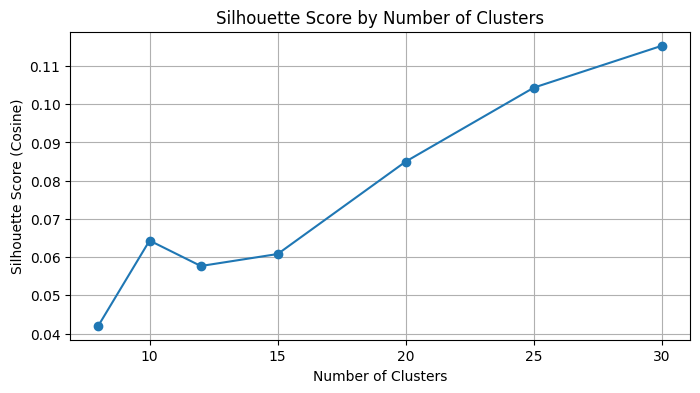

In [185]:
plt.figure(figsize=(8, 4))
plt.plot(cluster_metric_df["n_clusters"], cluster_metric_df["silhouette_cosine"], marker="o")

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score (Cosine)")
plt.grid(True)
plt.show()

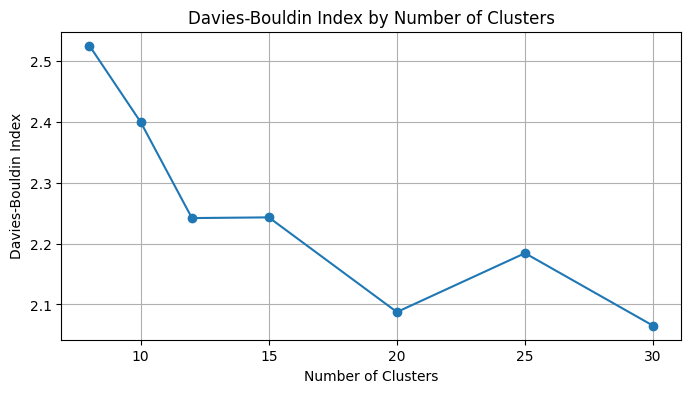

In [186]:
plt.figure(figsize=(8, 4))
plt.plot(cluster_metric_df["n_clusters"], cluster_metric_df["davies_bouldin"], marker="o")

plt.title("Davies-Bouldin Index by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Davies-Bouldin Index")
plt.grid(True)
plt.show()

In [187]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", 200)

meeting_closure_chunks = cluster_df[
    cluster_df["chunk_label"].astype(str).str.lower().str.contains("case closure", na=False)
][["chunk_label", "chunk_summary", "chunk_text"]]

meeting_closure_chunks

,chunk_label,chunk_summary,chunk_text


In [188]:
# Theme × call_type composition
pd.crosstab(cluster_df['cluster_id'], cluster_df['call_type'], normalize='index')

# Within each theme, sentiment by call_type
pd.crosstab(
    [cluster_df['cluster_id'], cluster_df['call_type']],
    cluster_df['chunk_sentiment'],
    normalize='index'
)

chunk_sentiment                  mixed-negative  mixed-positive  negative  \
cluster_id call_type                                                        
0          customer_facing             0.233766        0.064935  0.324675   
           internal_operational        0.181818        0.000000  0.409091   
1          customer_facing             0.083333        0.000000  0.000000   
           internal_operational        0.000000        0.000000  0.000000   
2          customer_facing             0.125000        0.041667  0.125000   
           internal_operational        0.058824        0.058824  0.176471   
3          customer_facing             0.103448        0.034483  0.172414   
           internal_operational        0.333333        0.000000  0.000000   
4          customer_facing             0.000000        0.000000  0.000000   
           internal_operational        0.000000        0.000000  0.333333   
5          internal_operational        0.000000        0.250000  0.000000   
6          customer_facing             0.029412        0.029412  0.058824   
           internal_operational        0.083333        0.083333  0.000000   
7          customer_facing             0.000000        0.000000  0.000000   
           internal_operational        0.000000        0.000000  0.000000   
8          internal_operational        0.000000        0.000000  0.000000   
9          customer_facing             0.000000        0.000000  0.000000   
           internal_operational        0.000000        0.142857  0.428571   
10         customer_facing             0.800000        0.000000  0.000000   
11         internal_operational        0.000000        0.000000  0.000000   
12         internal_operational        0.000000        0.000000  0.000000   
13         customer_facing             0.000000        0.000000  0.000000   
14         customer_facing             0.000000        0.285714  0.285714   
15         customer_facing             0.000000        0.000000  0.000000   
16         customer_facing             0.600000        0.000000  0.200000   
17         internal_operational        0.000000        0.000000  0.000000   
18         customer_facing             0.500000        0.000000  0.333333   
19         internal_operational        0.222222        0.000000  0.000000   

chunk_sentiment                   neutral  positive  very-negative  \
cluster_id call_type                                                 
0          customer_facing       0.246753  0.116883       0.012987   
           internal_operational  0.318182  0.090909       0.000000   
1          customer_facing       0.000000  0.916667       0.000000   
           internal_operational  0.000000  1.000000       0.000000   
2          customer_facing       0.291667  0.416667       0.000000   
           internal_operational  0.323529  0.352941       0.000000   
3          customer_facing       0.275862  0.413793       0.000000   
           internal_operational  0.333333  0.333333       0.000000   
4          customer_facing       0.000000  1.000000       0.000000   
           internal_operational  0.500000  0.166667       0.000000   
5          internal_operational  0.250000  0.500000       0.000000   
6          customer_facing       0.176471  0.705882       0.000000   
           internal_operational  0.333333  0.500000       0.000000   
7          customer_facing       0.382353  0.617647       0.000000   
           internal_operational  0.500000  0.500000       0.000000   
8          internal_operational  0.000000  1.000000       0.000000   
9          customer_facing       0.000000  1.000000       0.000000   
           internal_operational  0.428571  0.000000       0.000000   
10         customer_facing       0.200000  0.000000       0.000000   
11         internal_operational  0.000000  1.000000       0.000000   
12         internal_operational  0.000000  1.000000       0.000000   
13         customer_facing       0.000000  1.000000       0.000000   
14       

In [189]:
# Cross-domain chunks
cross = cluster_df[cluster_df['is_cross_domain'] == True]

# For each cross-domain chunk, find external calls referencing same client/topic

In [190]:
# For cluster 0 specifically
sub = cluster_df[cluster_df['cluster_id'] == 0]
X = np.array(sub['embedding'].tolist())

sub_model = AgglomerativeClustering(n_clusters=2, metric='cosine', linkage='average')
sub_labels = sub_model.fit_predict(X)

cluster_df.loc[sub.index, 'subcluster_id'] = sub_labels

In [161]:
sub = cluster_df[cluster_df['cluster_id'] == 0]
sub.groupby('subcluster_id').size().sort_values(ascending=False)

subcluster_id
1.0    57
0.0    42
dtype: int64